# Instructions

**Please follow these instructions carefully to ensure your submission is graded correctly:**

- Fill in **your answers** in any place that says "YOUR CODE HERE" or "YOUR ANSWER HERE" in the provided `.ipynb` files.

- Do not use print statements or the variable name `_` to display your answers; instead, make sure the last line of the cell contains the variable that holds your answer.

- Your answers to code-based questions must be **generated from code**. Hardcoded answers will result in a deduction of points.  

- Do not change the **autograding cells** labelled with `"AUTOGRADING CELL - DO NOT TOUCH!"`. Modifying or deleting them may lead to incorrect grading results.

- All plots must have appropriate **axis labels** including units where applicable. Failing to do so will result in a partial deduction of points.

- Always proide **units** for quantities where applicable. Failing to do so will result in a partial deduction of points.

- The **code quality** will not be graded. However, concise, well-structured code makes it easier to awared partial points in case of errors.

- The quality of **written answers** and **figures** will be considered during grading.

- Do not use additional packages that are not part of the course **environment**. This would lead to errors during autograding.

- Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

- Submissions must be your own work, **plagiarism** from the web or peers will be checked for and sanctioned.

- Please upload only the provided `.ipynb` files, filled in with your answers.

- Please **do not** put the `.ipynb` files into archives (e.g., `.zip`, `.tar.gz`); also `.py` files will **not** be accepted. Please **do not change the file names** and do not upload additional files.

- Submission on ISIS *(for TU Berlin students)* requires **two-factor authentication**.

---

## Task 3: Nuclear Power Plants in Global Energy Monitor (55 points)

In this task, we are going to look at the [Global Nuclear Power Tracker](https://globalenergymonitor.org/projects/global-nuclear-power-tracker/) published by [Global Energy Monitor](https://globalenergymonitor.org/) with a focus on the locations and capacities of nuclear power plants worldwide.

In [155]:
url = "https://tubcloud.tu-berlin.de/s/d5Qt3JWNEseMNGN/download/Global-Nuclear-Power-Tracker-September-2025.xlsx"

In [3]:
import cartopy
import numpy as np
import pandas as pd
import geopandas as gpd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

**a)** Read the Excel file from the link above (`url`) with `pandas` and use the provided coordinates to convert it into a `geopandas.GeoDataFrame` named `gdf` with the appropriate coordinate reference system (CRS). Set the index to the "GEM unit ID" column . **(4 points)**

In [ ]:
# YOUR CODE HERE
df = pd.read_excel(url, sheet_name="Data")
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),
    crs="EPSG:4326"
)
gdf.set_index("GEM unit ID", inplace=True)
gdf

,Date Last Researched,Country/Area,Project Name,Unit Name,Project Name in Local Language / Script,Other Name(s),Capacity (MW),Status,Reactor Type,Model,...,Location Accuracy,City,"Local Area (taluk, county)","Major Area (prefecture, district)",State/Province,Subregion,Region,GEM location ID,Wiki URL,geometry
GEM unit ID,,,,,,,,,,,,,,,,,,,,,
G100000500502,2024-05-22,Argentina,Atucha nuclear power plant,1,NaN,Unit IV (Phase 3),362.0,operating,pressurized heavy water reactor,PHWR KWU,...,exact,NaN,NaN,Partido de Zárate,Buenos Aires,Latin America and the Caribbean,Americas,L100000500166,https://www.gem.wiki/Atucha_nuclear_power_plant,POINT (-59.2095 -33.96701)
G100000500382,2024-05-22,Argentina,Atucha nuclear power plant,2,NaN,Unit IV (Phase 3),745.0,operating,pressurized heavy water reactor,PHWR KWU,...,exact,NaN,NaN,Partido de Zárate,Buenos Aires,Latin America and the Caribbean,Americas,L100000500166,https://www.gem.wiki/Atucha_nuclear_power_plant,POINT (-59.2073 -33.9672)
G100000500646,2025-07-09,Argentina,Atucha nuclear power plant,3,NaN,Unit IV (Phase 3),1150.0,shelved,pressurized water reactor,Hualong One,...,exact,NaN,NaN,Partido de Zárate,Buenos Aires,Latin America and the Caribbean,Americas,L100000500166,https://www.gem.wiki/Atucha_nuclear_power_plant,POINT (-59.2075 -33.9672)
G100001055220,2025-07-09,Argentina,Atucha nuclear power plant,SMR 1,NaN,Unit IV (Phase 3),300.0,announced,small modular reactor,ACR-300,...,exact,Atucha,NaN,NaN,NaN,Latin America and the Caribbean,Americas,L100000500166,https://www.gem.wiki/Atucha_nuclear_power_plant,POINT (-59.20774 -33.9687)
G100001055221,2025-07-09,Argentina,Atucha nuclear power plant,SMR 2,NaN,Unit IV (Phase 3),300.0,announced,small modular reactor,ACR-300,...,exact,Atucha,NaN,NaN,NaN,Latin America and the Caribbean,Americas,L100000500166,https://www.gem.wiki/Atucha_nuclear_power_plant,POINT (-59.20774 -33.9687)


In [21]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(gdf, gpd.GeoDataFrame)

In [22]:
### AUTOGRADING CELL - DO NOT TOUCH!

In [23]:
### AUTOGRADING CELL - DO NOT TOUCH!

In [ ]:
### AUTOGRADING CELL - DO NOT TOUCH!

**b)** Find the operating nuclear power plants with a start year of 2025 and list their project names as a Python list or `numpy.ndarray`. **(2 points)**

In [157]:
# YOUR CODE HERE
# gdf.columns.tolist()
gdf[(gdf["Start Year"] == 2025) & (gdf["Status"] == "operating")]["Project Name"].tolist()

['Zhangzhou nuclear power plant', 'Rajasthan nuclear power plant']

In [151]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, list | np.ndarray)

In [152]:
### AUTOGRADING CELL - DO NOT TOUCH!

**c)** Find and list the seven countries with the largest announced nuclear power plant capacity (in GW) in descending order as a `pandas.Series` with countries as the index and capacities as the values. **(3 points)**

In [33]:
# YOUR CODE HERE
# gdf.columns.tolist()
announced_gdf = gdf[gdf['Status'] == 'announced']
country_capacities = announced_gdf.groupby('Country/Area')['Capacity (MW)'].sum() / 1000
top_seven_announced = country_capacities.sort_values(ascending=False).head(7)
top_seven_announced

Country/Area
China            59.662
Russia           20.815
Uganda           18.000
Poland           11.862
Türkiye           9.900
Kazakhstan        9.600
United States     7.757
Name: Capacity (MW), dtype: float64

In [34]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)

In [35]:
### AUTOGRADING CELL - DO NOT TOUCH!

**d)** What share (in %) of the operating nuclear power plant fleet has a determined retirement year? Return a single float value. **(3 points)**

In [158]:
# YOUR CODE HERE
operating_gdf = gdf[gdf["Status"] == "operating"]
(operating_gdf["Planned Retirement"].notna().sum() / len(operating_gdf)) * 100

np.float64(8.31353919239905)

In [159]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

In [160]:
### AUTOGRADING CELL - DO NOT TOUCH!

**e)** Plot a bar chart which shows the capacity per country (in GW electric) that will be retired by the end of 2045 in ascending order. For power plants with no set retirement year, assume a lifetime of 45 years after commissioning. For all other power plants, use the provided retirement year. **(5 points)**

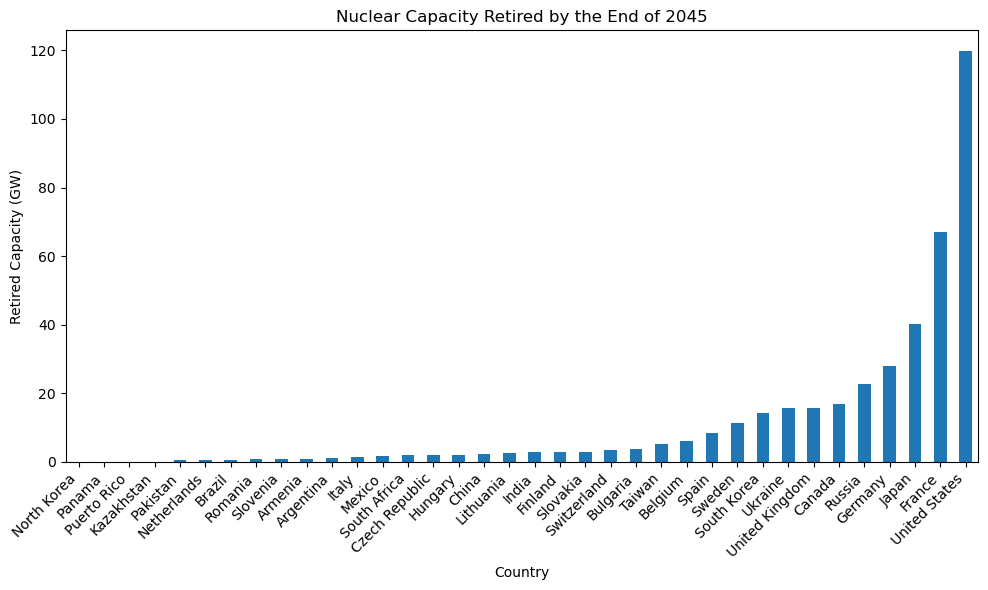

In [46]:
# YOUR CODE HERE
retirement = pd.to_numeric(df["Planned Retirement"], errors="coerce")
start = pd.to_numeric(df["Start Year"], errors="coerce")
calculated_retirement = retirement.fillna(start + 45)
retired_capacity_gw = (
    pd.to_numeric(df["Capacity (MW)"], errors="coerce")
    .loc[calculated_retirement <= 2045]
    .groupby(df["Country/Area"])
    .sum() / 1000
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
retired_capacity_gw.plot(kind="bar", ax=ax)

ax.set_xlabel("Country")
ax.set_ylabel("Retired Capacity (GW)")
ax.set_title("Nuclear Capacity Retired by the End of 2045")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


**f)** For operating power plants with given information on the construction start date and the commercial operation data, compute the median construction time in years. Use the function `pd.to_datetime` to convert the date columns to datetime objects. **(4 points)**

In [66]:
# YOUR CODE HERE
operating_df = df[df["Status"] == "operating"]

with_both = operating_df[
    operating_df["Construction Start Date"].notna() & 
    operating_df["Commercial Operation Date"].notna()
]

construction_start = pd.to_datetime(
    with_both["Construction Start Date"], 
    format='mixed', 
    errors='coerce'
)
commercial_operation = pd.to_datetime(
    with_both["Commercial Operation Date"], 
    format='mixed', 
    errors='coerce'
)

construction_time_days = (commercial_operation - construction_start).dt.days
median_construction_time = construction_time_days.median() / 365.25

median_construction_time


7.123887748117728

In [67]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

In [68]:
### AUTOGRADING CELL - DO NOT TOUCH!

**g)** Compute the capacity-weighted mean age (in years) of all operating nuclear power plants. **(3 points)**

In [88]:
# YOUR CODE HERE
operating_df = df[df["Status"] == "operating"]
age = 2025 - operating_df["Start Year"]
mean_age = sum(age*operating_df["Capacity (MW)"])/sum(operating_df["Capacity (MW)"])
mean_age

31.16905574062954

In [89]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

In [90]:
### AUTOGRADING CELL - DO NOT TOUCH!

**h)** For each country, compute the average age of its operating nuclear power plants weighted by their operational capacity.
Return the mean ages as a `pandas.Series` in ascending order with the country names as the index and the mean ages as the values. **(4 points)**

In [93]:
# YOUR CODE HERE
operating_df = df[df["Status"] == "operating"]
operating_df["Age"] = 2025 - operating_df["Start Year"]
out = (
    operating_df
    .groupby("Country/Area")
    .apply(lambda g: (g["Age"] * g["Capacity (MW)"]).sum() / g["Capacity (MW)"].sum())
    .sort_values(ascending=True)
)
out

/var/folders/1s/5g1n6w4x0ksckcmsmvfzf3zw0000gn/T/ipykernel_16049/126311216.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  operating_df["Age"] = 2025 - operating_df["Start Year"]
/var/folders/1s/5g1n6w4x0ksckcmsmvfzf3zw0000gn/T/ipykernel_16049/126311216.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g["Age"] * g["Capacity (MW)"]).sum() / g["Capacity (MW)"].sum())


Country/Area
United Arab Emirates     2.500000
Belarus                  3.000000
Pakistan                 7.409348
China                   10.103419
Iran                    12.000000
India                   14.995146
South Korea             22.289904
Romania                 23.503898
Slovakia                27.091056
Russia                  28.408140
Brazil                  29.145729
Finland                 29.401125
Argentina               29.530913
Czech Republic          30.425072
Mexico                  32.503109
Japan                   33.375462
Bulgaria                34.500000
United Kingdom          34.956535
Ukraine                 35.224069
France                  37.383833
Spain                   39.553051
North Korea             40.000000
Hungary                 40.002960
South Africa            40.500000
Canada                  40.929660
Slovenia                42.000000
United States           42.220561
Sweden                  42.344098
Belgium                 44.680176
A

In [94]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)
assert "France" in _.index

In [95]:
### AUTOGRADING CELL - DO NOT TOUCH!

In [96]:
### AUTOGRADING CELL - DO NOT TOUCH!

**i)** List the names of the operators of the operating Swedish nuclear power plants in descending order of total capacity operated. Return a `pandas.Series` with operator names as the index and total capacities (in GW) as the values. **(3 points)**

In [99]:
# YOUR CODE HERE
operating_df[operating_df["Country/Area"] == "Sweden"]
sorted_operators = operating_df.groupby("Operator")["Capacity (MW)"].sum().sort_values(ascending=False)
sorted_operators

Operator
Electricité de France                                       65690.0
Rosenergoatom                                               28576.0
Korea Hydro & Nuclear Power                                 27071.0
Exelon Generation                                           22689.0
SE NNEGC "Energoatom"                                       13835.0
                                                             ...   
Nuklearna Elektrarna Krško                                    727.0
New Brunswick Electric Power Commission                       705.0
N.V. Elektriciteits-Produktiemaatschappij Zuid-Nederland      515.0
Closed Joint Stock Company Armenian NPP                       448.0
Huaneng Shandong Shidao Bay Nuclear Power                     211.0
Name: Capacity (MW), Length: 84, dtype: float64

In [100]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)

In [101]:
### AUTOGRADING CELL - DO NOT TOUCH!

In [102]:
### AUTOGRADING CELL - DO NOT TOUCH!

**j)** Find the most common operational reactor type (by number of reactors) of each country with operational nuclear power plants. Return a `pandas.Series` with countries as the index and reactor types as the values. **(3 points)**

In [121]:
# YOUR CODE HERE
counts = operating_df.groupby(["Country/Area", "Reactor Type"]).size()
most_common = counts.groupby("Country/Area").idxmax().str[1]
most_common


Country/Area
Argentina               pressurized heavy water reactor
Armenia                       pressurized water reactor
Belarus                       pressurized water reactor
Belgium                       pressurized water reactor
Brazil                        pressurized water reactor
Bulgaria                      pressurized water reactor
Canada                  pressurized heavy water reactor
China                         pressurized water reactor
Czech Republic                pressurized water reactor
Finland                       pressurized water reactor
France                        pressurized water reactor
Hungary                       pressurized water reactor
India                   pressurized heavy water reactor
Iran                          pressurized water reactor
Japan                         pressurized water reactor
Mexico                            boiling water reactor
Netherlands                   pressurized water reactor
North Korea                        

In [122]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)
assert "China" in _.index

In [123]:
### AUTOGRADING CELL - DO NOT TOUCH!

**k)** For each country, find the most common operating reactor model by total capacity. Return a `pandas.Series` with countries as the index and the most common reactor model as the values. **(4 points)**

In [125]:
# YOUR CODE HERE
capacity = operating_df.groupby(["Country/Area", "Model"])["Capacity (MW)"].sum()
most_common_model = capacity.groupby("Country/Area").idxmax().str[1]
most_common_model

Country/Area
Argentina                                    PHWR KWU
Armenia                                    VVER V-270
Belarus                                    VVER V-491
Belgium                                        WH 3LP
Brazil                                     PRE KONVOI
Bulgaria                                   VVER V-320
Canada                                      CANDU 850
China                                        CPR-1000
Czech Republic                             VVER V-320
Finland                              AA-III, BWR-2500
France                                    P4 REP 1300
Hungary                                    VVER V-213
India                   Horizontal Pressure Tube type
Iran                                       VVER V-446
Japan                                      M (3-loop)
Mexico                                          BWR-5
Netherlands                                   KWU 2LP
North Korea                                    MAGNOX
Pakistan       

In [126]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)
assert "France" in _.index

In [127]:
### AUTOGRADING CELL - DO NOT TOUCH!

In [128]:
### AUTOGRADING CELL - DO NOT TOUCH!

**l)** Visualise the locations of operating nuclear power plants on a map covering roughly Pakistan, India, China, Japan, South Korea and North Korea. Ensure the following criteria are met: **(5 points)**

- Use the Mercator projection and a figure size of approximately 15x10 inches.
- The size of the points should be proportional to the capacity of the power plants (no legend required).
- The color of the points should indicate the start year of the power plants.
- The map should include coastlines and country borders; the background should be white.

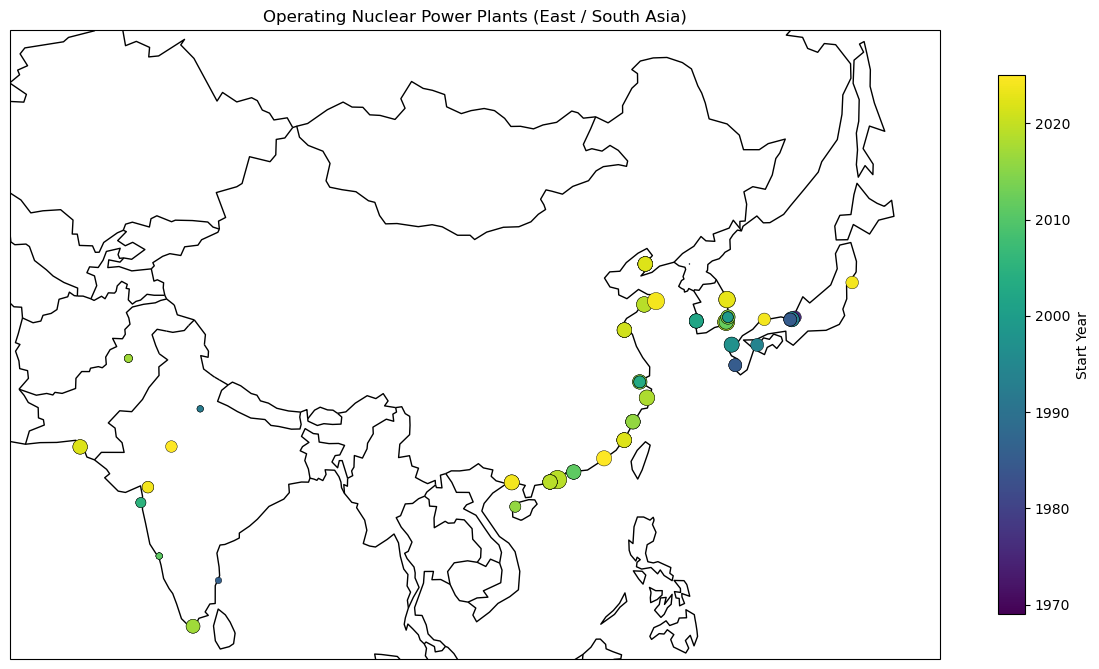

In [131]:
# YOUR CODE HERE
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.Mercator())
ax.set_extent([60, 150, 5, 55], crs=ccrs.PlateCarree())
ax.set_facecolor('white')
operating_gdf = gdf[gdf["Status"] == "operating"]
scatter = ax.scatter(
    operating_gdf.geometry.x,
    operating_gdf.geometry.y,
    s=operating_gdf["Capacity (MW)"] / 10,
    c=operating_gdf["Start Year"],
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    edgecolors="k",
    linewidths=0.3,
    zorder=5,
)
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS)
plt.colorbar(scatter, ax=ax, label="Start Year", shrink=0.7)
ax.set_title("Operating Nuclear Power Plants (East / South Asia)")
plt.show()



**In the following, we additionally want to aggregate data on nuclear power plants in Europe to various NUTS levels. The NUTS region data can be read with `geopandas` using the URL (`url_nuts`) below:**

In [132]:
url_nuts = "https://tubcloud.tu-berlin.de/s/5WJ6pGsBKR7a3sp/download/NUTS_RG_10M_2021_4326.geojson"

**m)** Calculate the area (in square kilometers) of each NUTS 2 region and return it as a `pandas.Series` with the NUTS 2 region codes as the index (sorted alphabetically) and the areas as the values. **(4 points)**

In [139]:
# YOUR CODE HERE
nuts = gpd.read_file(url_nuts)
nuts = nuts[nuts["LEVL_CODE"] == 2]
nuts["area_km2"] = nuts.geometry.area / 1000000
nuts
nuts.set_index("NUTS_ID", inplace=True)
nuts.sort_index(inplace=True)
nuts["area_km2"]


/var/folders/1s/5g1n6w4x0ksckcmsmvfzf3zw0000gn/T/ipykernel_16049/1669338204.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  nuts["area_km2"] = nuts.geometry.area / 1000000


NUTS_ID
AL01    1.178833e-06
AL02    5.330068e-07
AL03    1.378250e-06
AT11    4.736795e-07
AT12    2.320692e-06
            ...     
UKM6    6.202066e-06
UKM7    1.956551e-06
UKM8    2.773880e-07
UKM9    2.245808e-06
UKN0    1.961795e-06
Name: area_km2, Length: 334, dtype: float64

In [140]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)

In [141]:
### AUTOGRADING CELL - DO NOT TOUCH!

In [142]:
### AUTOGRADING CELL - DO NOT TOUCH!

**n)** Find the three NUTS 2 regions **outside of France** with the highest total capacity of operating nuclear power plants. Return a `pandas.Series` with the NUTS 2 region names (`NAME_LATN`, not the `NUTS_ID`) as the index and the total capacities (in MW) as the values. **(3 points)**

In [ ]:
# YOUR CODE HERE
# nuts[nuts["NUTS_ID"] != "FR"]
# operating_df
nuts_ex_fr = nuts[~nuts.index.str.startswith("FR")].reset_index()
overlay = gpd.overlay(operating_gdf, nuts_ex_fr.to_crs(4326))
result = (
    overlay.groupby("NAME_LATN")["Capacity (MW)"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
)
result

NAME_LATN
Östra Mellansverige    3446.0
Cataluña               3147.0
Západné Slovensko      2471.0
Name: Capacity (MW), dtype: float64

In [146]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)

In [147]:
### AUTOGRADING CELL - DO NOT TOUCH!

**o)** Plot a choropleth map of NUTS3 regions with `matplotlib` which shows each region's total announced nuclear power plant capacity (in MW). The following criteria must be met: **(5 points)**

- The figure size should be approximately 15x10 inches.
- Use the EqualEarth projection.
- Coastlines and country borders should be included in black.
- Set the geographical bounds to focus on continental Europe.
- Use the colormap `"plasma"` starting from value 0.
- Include an appropriately labeled colorbar to the right-hand side of the plot.
- Regions with no announced nuclear power plants should be grey and hatched.

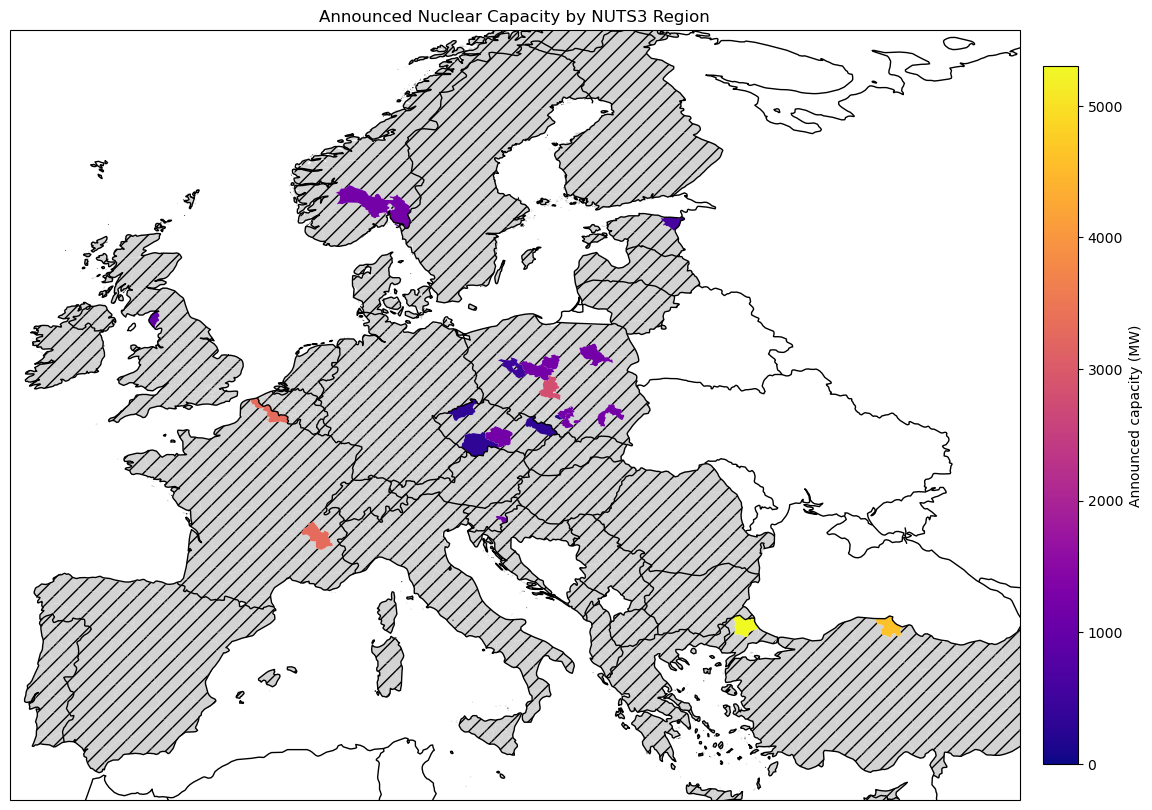

In [149]:
# YOUR CODE HERE
announced_gdf = gdf[gdf["Status"] == "announced"]
nuts = gpd.read_file(url_nuts)
nuts3 = nuts[nuts["LEVL_CODE"] == 3].copy()

overlay = gpd.overlay(announced_gdf, nuts3.to_crs(4326))
cap_by_nuts = overlay.groupby("NUTS_ID")["Capacity (MW)"].sum()
nuts3 = nuts3.set_index("NUTS_ID")
nuts3["announced_mw"] = cap_by_nuts
nuts3["announced_mw"] = nuts3["announced_mw"].fillna(0)
has_cap = nuts3[nuts3["announced_mw"] > 0]
no_cap = nuts3[nuts3["announced_mw"] == 0]

proj = ccrs.EqualEarth()
fig, ax = plt.subplots(figsize=(15, 10), subplot_kw={"projection": proj})
ax.set_extent([-10, 40, 35, 70], crs=ccrs.PlateCarree())  # lon/lat bounds
ax.set_facecolor("white")
ax.add_feature(cartopy.feature.BORDERS, edgecolor="black")
ax.add_feature(cartopy.feature.COASTLINE, edgecolor="black")

no_cap.to_crs(proj).plot(
    ax=ax,
    color="lightgrey",
    edgecolor="none",
    hatch="//",
    linewidth=0,
)

plot = has_cap.to_crs(proj).plot(
    ax=ax,
    column="announced_mw",
    cmap="plasma",
    vmin=0,
    legend=False,
)

sm = plt.cm.ScalarMappable(
    cmap="plasma",
    norm=plt.Normalize(vmin=0, vmax=has_cap["announced_mw"].max()),
)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Announced capacity (MW)")
ax.set_title("Announced Nuclear Capacity by NUTS3 Region")
plt.show()
